In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np

# check statistics of text embeddings

In [2]:
file = "/workspace/data/preprocessed/text_embeddings/text_embeddings_mean_nsdDoerig.pt"

text_embeddings = torch.load(file, map_location="cpu")

In [3]:
print(text_embeddings.shape)

torch.Size([73000, 768])


# check cosine similarity for pairs of embeddings

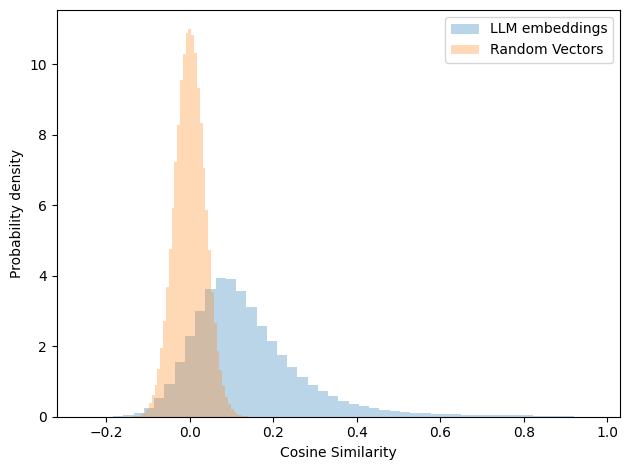

In [10]:
# check whether embeddings are bunched up or not. 
# Memory efficient version with subsampling
sample_size = 1000
data_num, embs_dim = text_embeddings.shape

# random sampling
rand_data_indices = np.random.choice(data_num, size=min(sample_size, data_num), replace=False)
embs_sampled = text_embeddings[rand_data_indices].numpy()

# compute cosine similarity for all unique pairs
n_sampled = len(embs_sampled)
sim_matrix = embs_sampled @ embs_sampled.T
tri_i, tri_j = np.triu_indices(n_sampled, k=1)
similarities = sim_matrix[tri_i, tri_j]

plt.hist(similarities, bins=50, alpha=0.3, label="LLM embeddings",  density=True)

random_vectors = np.random.randn(sample_size, embs_dim)

# Normalize to unit vectors (to make them comparable with text embeddings)
random_vectors = random_vectors / np.linalg.norm(random_vectors, axis=1, keepdims=True)

# Compute cosine similarity for all unique pairs
sim_matrix_random = random_vectors @ random_vectors.T
tri_i_random, tri_j_random = np.triu_indices(sample_size, k=1)
similarities_random = sim_matrix_random[tri_i_random, tri_j_random]

plt.hist(similarities_random, bins=50, alpha=0.3, label='Random Vectors', density=True)
plt.xlabel("Cosine Similarity")
plt.ylabel("Probability density")
plt.legend()

plt.tight_layout()
plt.show()

del embs_sampled, similarities
del random_vectors, sim_matrix_random, similarities_random